# Type 3 Band PSS Validation and Accuracy

This notebook evaluates Type-3 clone difficulty bands separately:

- `type3_very_strong`: `0.90 <= min(similarity_line, similarity_token) < 1.00`
- `type3_strong`: `0.70 <= min(similarity_line, similarity_token) < 0.90`
- `type3_moderate`: `0.50 <= min(similarity_line, similarity_token) < 0.70`

For each band, it compares that band's positive clone pairs against sampled Type-3 non-clone pairs, computes PSS distributions for every graph layer, and tunes a threshold to report accuracy/F1 per band.


In [1]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from tqdm.auto import tqdm


def find_project_root(start=None):
    path = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "pipelines").exists() and (candidate / "spectral_code").exists():
            return candidate
    raise RuntimeError("Could not find Spectral-Software project root.")

PROJECT_ROOT = find_project_root()
BENCH_DIR = PROJECT_ROOT / "bench_data" / "bcb_full_type3"
BANDS_DIR = BENCH_DIR / "similarity_bands"
OUTPUT_ROOT = PROJECT_ROOT.parent / "outputs" / "type3"
SPECTRAL_MANIFEST_PATH = OUTPUT_ROOT / "spectral_features" / "spectral_features_manifest.json"
ANALYSIS_OUT = PROJECT_ROOT / "notebooks" / "bcb_full_type3" / "analysis_outputs"
ANALYSIS_OUT.mkdir(parents=True, exist_ok=True)

GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg", "cpg"]
BANDS = {
    "type3_moderate": {"label": "Moderate", "range": "0.50 <= similarity < 0.70"},
    "type3_strong": {"label": "Strong", "range": "0.70 <= similarity < 0.90"},
    "type3_very_strong": {"label": "Very Strong", "range": "0.90 <= similarity < 1.00"},
}
RANDOM_SEED = 42

# Balanced by default so the accuracy numbers are comparable across bands.
# To approximate the full Type-3 train mix, set this to 70 / 30.
NEGATIVE_RATIO_TO_POSITIVES = 1.0
MAX_POSITIVES_PER_BAND = None  # set to e.g. 5000 for fast exploratory runs
FORCE_RECOMPUTE_SCORES = False

print("Project root:", PROJECT_ROOT)
print("Type-3 bench dir:", BENCH_DIR)
print("Type-3 spectral manifest:", SPECTRAL_MANIFEST_PATH)


Project root: C:\Users\koush\PyProjects\Spectral-Software
Type-3 bench dir: C:\Users\koush\PyProjects\Spectral-Software\bench_data\bcb_full_type3
Type-3 spectral manifest: C:\Users\koush\PyProjects\outputs\type3\spectral_features\spectral_features_manifest.json


In [2]:
def load_pairs(path):
    rows = []
    with Path(path).open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            left, right, label = line.split("\t")[:3]
            rows.append((int(left), int(right), int(label)))
    return pd.DataFrame(rows, columns=["left_id", "right_id", "label"])


def load_band_positive_pairs():
    frames = []
    for band_name, info in BANDS.items():
        path = BANDS_DIR / band_name / "train_positives.txt"
        if not path.exists():
            raise FileNotFoundError(f"Missing band positives: {path}. Run 06_type3_similarity_band_subsets.ipynb first.")
        df = load_pairs(path)
        df["band"] = band_name
        df["band_label"] = info["label"]
        df["similarity_range"] = info["range"]
        if MAX_POSITIVES_PER_BAND is not None and len(df) > MAX_POSITIVES_PER_BAND:
            df = df.sample(MAX_POSITIVES_PER_BAND, random_state=RANDOM_SEED).reset_index(drop=True)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


train_df = load_pairs(BENCH_DIR / "train.txt")
parent_nonclones = train_df[train_df.label == 0].copy().reset_index(drop=True)
band_positives = load_band_positive_pairs()

display(Markdown("### Full Type-3 train class distribution"))
display(
    train_df["label"].value_counts().rename_axis("label").reset_index(name="pairs")
    .assign(fraction=lambda d: d["pairs"] / len(train_df))
)

display(Markdown("### Type-3 positive band counts"))
display(
    band_positives.groupby(["band", "band_label", "similarity_range"])
    .size().rename("positive_pairs").reset_index()
)


### Full Type-3 train class distribution

,label,pairs,fraction
0,0,70000,0.7
1,1,30000,0.3


### Type-3 positive band counts

,band,band_label,similarity_range,positive_pairs
0,type3_moderate,Moderate,0.50 <= similarity < 0.70,24490
1,type3_strong,Strong,0.70 <= similarity < 0.90,4823
2,type3_very_strong,Very Strong,0.90 <= similarity < 1.00,687


In [3]:
def make_band_eval_pairs():
    frames = []
    for band_name, pos in band_positives.groupby("band", sort=False):
        rng_seed = RANDOM_SEED + sum(ord(ch) for ch in band_name)
        pos = pos.copy()
        neg_count = min(len(parent_nonclones), int(round(len(pos) * NEGATIVE_RATIO_TO_POSITIVES)))
        neg = parent_nonclones.sample(neg_count, random_state=rng_seed).copy()
        neg["band"] = band_name
        neg["band_label"] = BANDS[band_name]["label"]
        neg["similarity_range"] = BANDS[band_name]["range"]
        frames.extend([pos, neg])
    pairs = pd.concat(frames, ignore_index=True)
    pairs = pairs.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    return pairs


eval_pairs = make_band_eval_pairs()
class_mix = (
    eval_pairs.groupby(["band", "band_label", "label"])
    .size().rename("pairs").reset_index()
)
class_mix["fraction_in_band_eval"] = class_mix["pairs"] / class_mix.groupby("band")["pairs"].transform("sum")
class_mix.to_csv(ANALYSIS_OUT / "type3_band_eval_class_mix.csv", index=False)

display(Markdown("### Evaluation class mix used by this notebook"))
display(class_mix)


### Evaluation class mix used by this notebook

,band,band_label,label,pairs,fraction_in_band_eval
0,type3_moderate,Moderate,0,24490,0.5
1,type3_moderate,Moderate,1,24490,0.5
2,type3_strong,Strong,0,4823,0.5
3,type3_strong,Strong,1,4823,0.5
4,type3_very_strong,Very Strong,0,687,0.5
5,type3_very_strong,Very Strong,1,687,0.5


In [4]:
def load_spectral_features_for_ids(method_ids):
    method_ids = {str(int(mid)) for mid in method_ids}
    manifest = json.loads(SPECTRAL_MANIFEST_PATH.read_text(encoding="utf-8"))
    features = {}
    for shard_path in tqdm(manifest["shards"], desc="Loading Type-3 spectral shards", unit="shard"):
        with open(shard_path, "rb") as f:
            shard = pickle.load(f)
        missing = method_ids - set(features)
        for method_id in list(missing):
            if method_id in shard:
                features[method_id] = shard[method_id]
        if len(features) == len(method_ids):
            break
    missing = method_ids - set(features)
    if missing:
        print(f"Warning: {len(missing):,} requested methods were not found in spectral shards.")
    return features


def informative_eigenvalues(record, graph_type, eps=1e-10):
    if not record:
        return None
    values = np.asarray(record.get(graph_type, {}).get("eigenvalues", []), dtype=float)
    if values.size == 0 or not np.all(np.isfinite(values)) or not np.any(np.abs(values) > eps):
        return None
    return values


def pss(ev1, ev2):
    ev1 = np.asarray(ev1, dtype=float)
    ev2 = np.asarray(ev2, dtype=float)
    nz1 = np.nonzero(ev1)[0]
    nz2 = np.nonzero(ev2)[0]
    if len(nz1) == 0 or len(nz2) == 0:
        return np.nan
    ev1 = ev1[:nz1[-1] + 1]
    ev2 = ev2[:nz2[-1] + 1]
    max_len = max(len(ev1), len(ev2))
    if len(ev1) != max_len:
        ev1 = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(ev1)), ev1)
    if len(ev2) != max_len:
        ev2 = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(ev2)), ev2)
    n1 = np.linalg.norm(ev1)
    n2 = np.linalg.norm(ev2)
    if n1 == 0 or n2 == 0:
        return np.nan
    distance = np.linalg.norm(ev1 / n1 - ev2 / n2)
    return float(np.clip((np.sqrt(2) - distance) / np.sqrt(2), 0.0, 1.0))


In [5]:
scores_cache = ANALYSIS_OUT / "type3_band_pss_scores.csv"

if scores_cache.exists() and not FORCE_RECOMPUTE_SCORES:
    scores_df = pd.read_csv(scores_cache)
else:
    needed_ids = set(eval_pairs.left_id).union(eval_pairs.right_id)
    features = load_spectral_features_for_ids(needed_ids)
    rows = []
    for pair in tqdm(eval_pairs.itertuples(index=False), total=len(eval_pairs), desc="Scoring band eval pairs", unit="pair"):
        left_record = features.get(str(pair.left_id))
        right_record = features.get(str(pair.right_id))
        for graph_type in GRAPH_TYPES:
            left_ev = informative_eigenvalues(left_record, graph_type)
            right_ev = informative_eigenvalues(right_record, graph_type)
            score = np.nan if left_ev is None or right_ev is None else pss(left_ev, right_ev)
            rows.append({
                "band": pair.band,
                "band_label": pair.band_label,
                "similarity_range": pair.similarity_range,
                "left_id": pair.left_id,
                "right_id": pair.right_id,
                "label": int(pair.label),
                "graph_type": graph_type,
                "pss": score,
                "status": "ok" if np.isfinite(score) else "missing_or_empty_spectrum",
            })
    scores_df = pd.DataFrame(rows)
    scores_df.to_csv(scores_cache, index=False)

missing_summary = (
    scores_df.groupby(["band", "band_label", "graph_type", "status"])
    .size().rename("pairs").reset_index()
)
missing_summary.to_csv(ANALYSIS_OUT / "type3_band_pss_missing_summary.csv", index=False)

display(Markdown("### PSS scoring status"))
display(missing_summary)
display(scores_df.head())


Loading Type-3 spectral shards:   0%|          | 0/147 [00:00<?, ?shard/s]

Scoring band eval pairs:   0%|          | 0/60000 [00:00<?, ?pair/s]

### PSS scoring status

,band,band_label,graph_type,status,pairs
0,type3_moderate,Moderate,ast,missing_or_empty_spectrum,4145
1,type3_moderate,Moderate,ast,ok,44835
2,type3_moderate,Moderate,cfg,missing_or_empty_spectrum,4145
3,type3_moderate,Moderate,cfg,ok,44835
4,type3_moderate,Moderate,cpg,missing_or_empty_spectrum,4145
5,type3_moderate,Moderate,cpg,ok,44835
6,type3_moderate,Moderate,ddg,missing_or_empty_spectrum,4163
7,type3_moderate,Moderate,ddg,ok,44817
8,type3_moderate,Moderate,pdg,missing_or_empty_spectrum,4163
9,type3_moderate,Moderate,pdg,ok,44817


,band,band_label,similarity_range,left_id,right_id,label,graph_type,pss,status
0,type3_moderate,Moderate,0.50 <= similarity < 0.70,6644757,20955453,1,ast,0.974621,ok
1,type3_moderate,Moderate,0.50 <= similarity < 0.70,6644757,20955453,1,cfg,0.978389,ok
2,type3_moderate,Moderate,0.50 <= similarity < 0.70,6644757,20955453,1,ddg,0.969220,ok
3,type3_moderate,Moderate,0.50 <= similarity < 0.70,6644757,20955453,1,pdg,0.968762,ok
4,type3_moderate,Moderate,0.50 <= similarity < 0.70,6644757,20955453,1,cpg,0.970689,ok


In [6]:
dist_summary = (
    scores_df[scores_df.status == "ok"]
    .groupby(["band", "band_label", "graph_type", "label"])["pss"]
    .agg(
        pairs="size",
        mean="mean",
        median="median",
        std="std",
        p10=lambda s: s.quantile(0.10),
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
    )
    .reset_index()
    .sort_values(["band", "graph_type", "label"])
)
dist_summary.to_csv(ANALYSIS_OUT / "type3_band_pss_distribution_summary.csv", index=False)
display(dist_summary)


,band,band_label,graph_type,label,pairs,mean,median,std,p10,p25,p75,p90
0,type3_moderate,Moderate,ast,0,23248,0.931331,0.934129,0.031441,0.891527,0.913194,0.953198,0.967744
1,type3_moderate,Moderate,ast,1,21587,0.977593,0.979186,0.009695,0.965293,0.972635,0.984235,0.987988
2,type3_moderate,Moderate,cfg,0,23248,0.929359,0.926776,0.037508,0.883655,0.903274,0.956314,0.980210
3,type3_moderate,Moderate,cfg,1,21587,0.974015,0.975591,0.012120,0.960127,0.967919,0.981839,0.986450
4,type3_moderate,Moderate,cpg,0,23248,0.938978,0.944229,0.029326,0.901180,0.924018,0.959653,0.969486
5,type3_moderate,Moderate,cpg,1,21587,0.977632,0.979604,0.010102,0.964526,0.973280,0.984411,0.987673
6,type3_moderate,Moderate,ddg,0,23230,0.937066,0.938018,0.029757,0.902143,0.921729,0.954296,0.972249
7,type3_moderate,Moderate,ddg,1,21587,0.964073,0.969425,0.019734,0.937858,0.957472,0.976436,0.981921
8,type3_moderate,Moderate,pdg,0,23230,0.935946,0.937223,0.030817,0.898918,0.920417,0.953959,0.972064
9,type3_moderate,Moderate,pdg,1,21587,0.965990,0.970247,0.017947,0.943410,0.959859,0.977226,0.982270


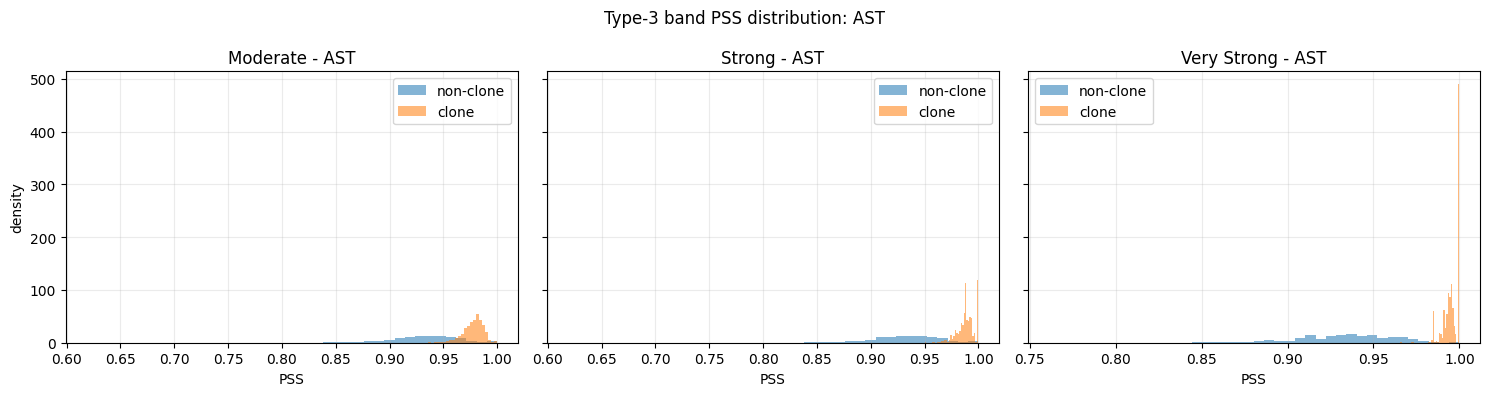

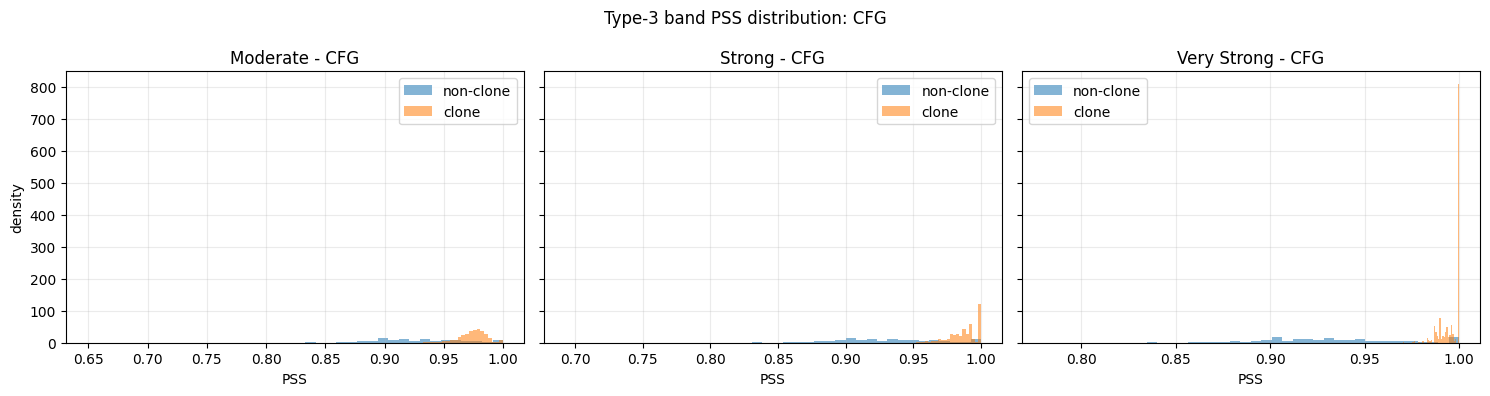

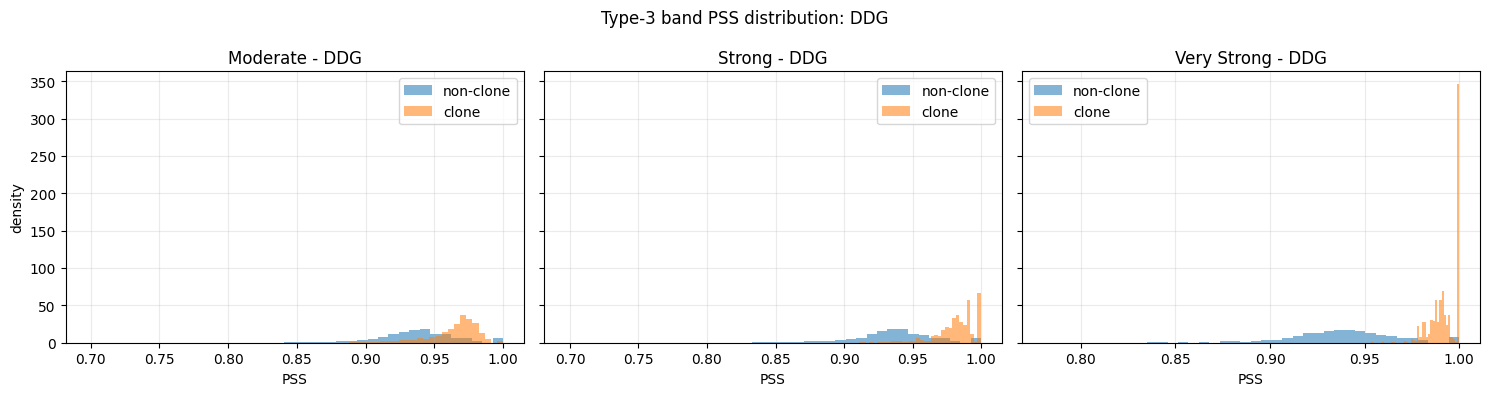

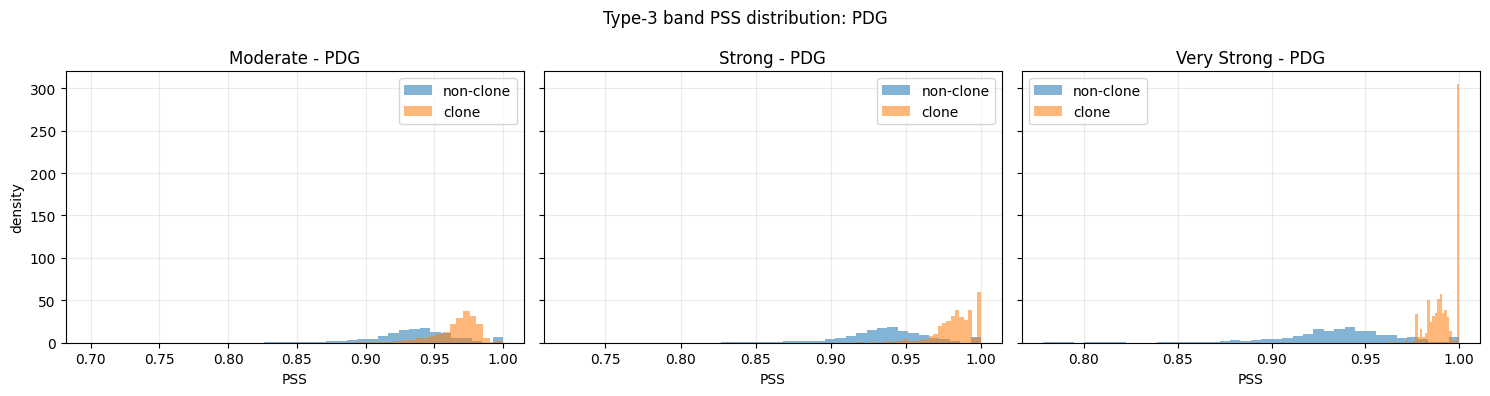

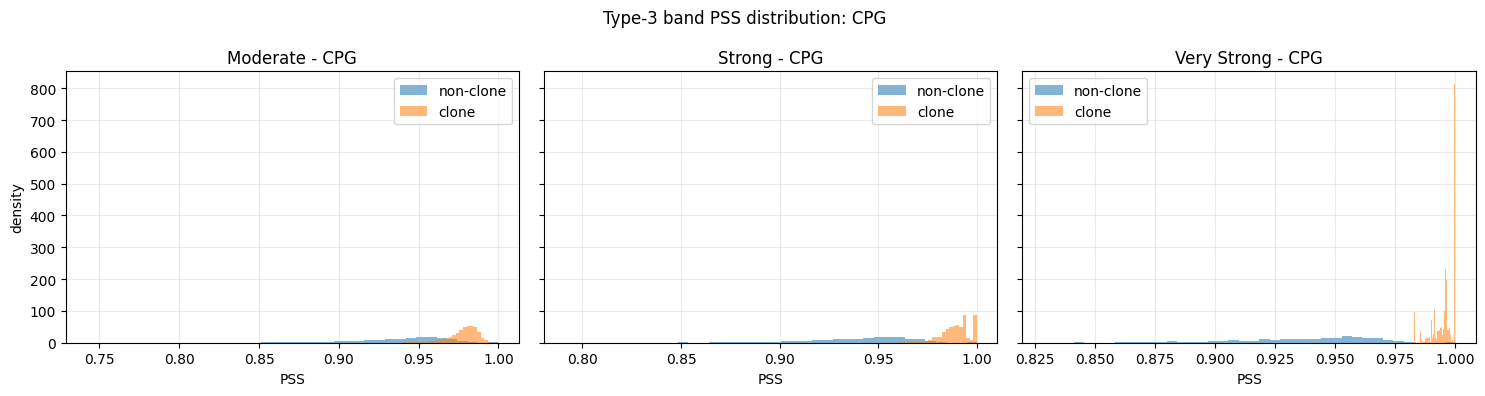

In [7]:
for graph_type in GRAPH_TYPES:
    fig, axes = plt.subplots(1, len(BANDS), figsize=(5 * len(BANDS), 4), sharey=True)
    if len(BANDS) == 1:
        axes = [axes]
    for ax, (band_name, info) in zip(axes, BANDS.items()):
        subset = scores_df[(scores_df.graph_type == graph_type) & (scores_df.band == band_name) & (scores_df.status == "ok")]
        pos = subset[subset.label == 1]["pss"]
        neg = subset[subset.label == 0]["pss"]
        ax.hist(neg, bins=40, alpha=0.55, label="non-clone", density=True)
        ax.hist(pos, bins=40, alpha=0.55, label="clone", density=True)
        ax.set_title(f"{info['label']} - {graph_type.upper()}")
        ax.set_xlabel("PSS")
        ax.grid(alpha=0.25)
        if ax is axes[0]:
            ax.set_ylabel("density")
        ax.legend()
    fig.suptitle(f"Type-3 band PSS distribution: {graph_type.upper()}")
    fig.tight_layout()
    plt.show()


In [8]:
def metric_row(labels, preds):
    labels = np.asarray(labels, dtype=int)
    preds = np.asarray(preds, dtype=int)
    tp = int(((labels == 1) & (preds == 1)).sum())
    tn = int(((labels == 0) & (preds == 0)).sum())
    fp = int(((labels == 0) & (preds == 1)).sum())
    fn = int(((labels == 1) & (preds == 0)).sum())
    accuracy = (tp + tn) / len(labels) if len(labels) else np.nan
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    balanced_accuracy = (recall + specificity) / 2
    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


def candidate_thresholds(scores):
    unique = np.unique(np.asarray(scores, dtype=float))
    candidates = {0.0, 1.0}
    candidates.update(float(x) for x in unique)
    if len(unique) > 1:
        mids = (unique[:-1] + unique[1:]) / 2.0
        candidates.update(float(x) for x in mids)
    return sorted(candidates)


def tune_threshold(scores, labels, optimize_for="f1"):
    best = None
    for threshold in candidate_thresholds(scores):
        preds = (np.asarray(scores) >= threshold).astype(int)
        row = metric_row(labels, preds)
        value = row[optimize_for]
        if best is None or value > best[optimize_for] or (value == best[optimize_for] and threshold > best["threshold"]):
            best = {"threshold": float(threshold), **row}
    return best


rows = []
for (band, band_label, graph_type), group in scores_df[scores_df.status == "ok"].groupby(["band", "band_label", "graph_type"]):
    labels = group["label"].to_numpy(dtype=int)
    if len(np.unique(labels)) < 2:
        continue
    result = tune_threshold(group["pss"].to_numpy(dtype=float), labels, optimize_for="f1")
    rows.append({
        "band": band,
        "band_label": band_label,
        "graph_type": graph_type,
        "valid_pairs": len(group),
        "positive_pairs": int((labels == 1).sum()),
        "negative_pairs": int((labels == 0).sum()),
        "positive_fraction": float((labels == 1).mean()),
        **result,
    })

metrics_df = pd.DataFrame(rows).sort_values(["band", "f1", "accuracy"], ascending=[True, False, False])
metrics_df.to_csv(ANALYSIS_OUT / "type3_band_pss_accuracy_by_graph.csv", index=False)
display(metrics_df)


,band,band_label,graph_type,valid_pairs,positive_pairs,negative_pairs,positive_fraction,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,tp,tn,fp,fn
0,type3_moderate,Moderate,ast,44835,21587,23248,0.481477,0.962214,0.889841,0.891363,0.852562,0.932459,0.850267,0.890723,20129,19767,3481,1458
2,type3_moderate,Moderate,cpg,44835,21587,23248,0.481477,0.966256,0.870146,0.870562,0.853396,0.881781,0.859343,0.867356,19035,19978,3270,2552
1,type3_moderate,Moderate,cfg,44835,21587,23248,0.481477,0.954901,0.837448,0.841107,0.772061,0.939871,0.742343,0.847742,20289,17258,5990,1298
4,type3_moderate,Moderate,pdg,44817,21587,23230,0.481670,0.952055,0.781556,0.783564,0.741772,0.838329,0.728799,0.787100,18097,16930,6300,3490
3,type3_moderate,Moderate,ddg,44817,21587,23230,0.481670,0.951997,0.765312,0.766890,0.731579,0.809932,0.723848,0.768764,17484,16815,6415,4103
7,type3_strong,Strong,cpg,8613,4030,4583,0.467897,0.974165,0.952514,0.952893,0.940833,0.958809,0.946978,0.949736,3864,4340,243,166
5,type3_strong,Strong,ast,8613,4030,4583,0.467897,0.973771,0.949727,0.950006,0.939194,0.954342,0.945669,0.946708,3846,4334,249,184
6,type3_strong,Strong,cfg,8613,4030,4583,0.467897,0.966801,0.890050,0.893734,0.836352,0.951117,0.836352,0.890050,3833,3833,750,197
9,type3_strong,Strong,pdg,8610,4030,4580,0.468060,0.964563,0.889199,0.890905,0.856019,0.917618,0.864192,0.885749,3698,3958,622,332
8,type3_strong,Strong,ddg,8610,4030,4580,0.468060,0.963187,0.881185,0.883089,0.845553,0.912903,0.853275,0.877938,3679,3908,672,351


In [9]:
best_graph_per_band = (
    metrics_df.sort_values(["band", "f1", "accuracy"], ascending=[True, False, False])
    .groupby("band", as_index=False)
    .head(1)
    .sort_values("band")
)
best_graph_per_band.to_csv(ANALYSIS_OUT / "type3_band_pss_best_graph_per_band.csv", index=False)

display(Markdown("### Best graph layer per Type-3 similarity band"))
display(best_graph_per_band)


### Best graph layer per Type-3 similarity band

,band,band_label,graph_type,valid_pairs,positive_pairs,negative_pairs,positive_fraction,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,tp,tn,fp,fn
0,type3_moderate,Moderate,ast,44835,21587,23248,0.481477,0.962214,0.889841,0.891363,0.852562,0.932459,0.850267,0.890723,20129,19767,3481,1458
7,type3_strong,Strong,cpg,8613,4030,4583,0.467897,0.974165,0.952514,0.952893,0.940833,0.958809,0.946978,0.949736,3864,4340,243,166
12,type3_very_strong,Very Strong,cpg,1257,609,648,0.484487,0.983107,0.993636,0.993778,0.988618,0.998358,0.989198,0.993464,608,641,7,1
